# Analysis notebook

/tmp/ipykernel_12418/819585245.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


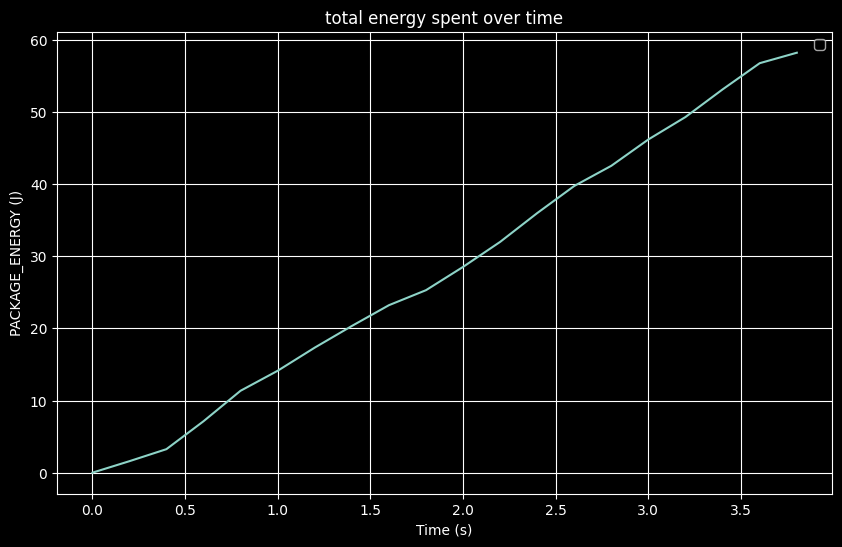

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

basepath = "data/out/energibridge_runs_all_languages/"
df = pd.read_csv(basepath + "python_measured_01.csv")
system_power_key = "PACKAGE_ENERGY (J)"
#system_power_key = "PP0_ENERGY (J)"     #cpu
#system_power_key = "PP1_ENERGY (J)"       #integrated graphics


plt.figure(figsize=(10, 6))
df['Time'] = df['Time'] - df['Time'].iloc[0]
df[system_power_key] = df[system_power_key] - df[system_power_key].iloc[0]
plt.plot(df['Time']/1000, df[system_power_key])

plt.xlabel('Time (s)')
plt.ylabel(system_power_key)
plt.title("total energy spent over time")
plt.legend()
plt.grid()
plt.show()

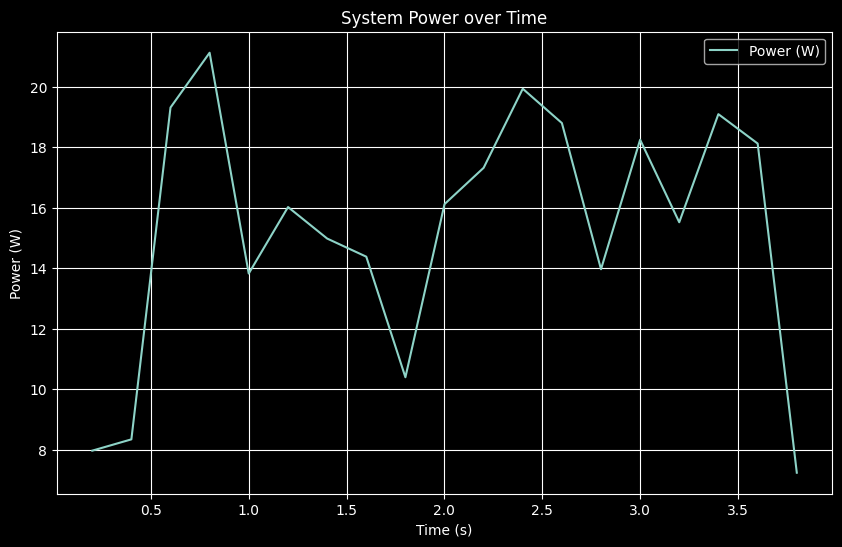

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

basepath = "data/out/energibridge_runs_all_languages/"
df = pd.read_csv(basepath + "python_measured_01.csv")

system_power_key = "PACKAGE_ENERGY (J)"
# system_power_key = "PP0_ENERGY (J)"   # CPU
# system_power_key = "PP1_ENERGY (J)"   # Integrated graphics

df['Time'] = df['Time'] - df['Time'].iloc[0]

df['Time_s'] = df['Time'] / 1000

# Compute differences
dE = df[system_power_key].diff()       # Joules
dt = df['Time_s'].diff()               # Seconds

df['Power_W'] = dE / dt

df = df.dropna()

# Plot
plt.figure(figsize=(10, 6))
plt.plot(df['Time_s'], df['Power_W'], label='Power (W)')

plt.xlabel('Time (s)')
plt.ylabel('Power (W)')
plt.title('System Power over Time')
plt.legend()
plt.grid()
plt.show()

In [10]:
import pandas as pd
import numpy as np
import os

basepath = "data/out/energibridge_runs_all_languages"
system_energy_key = "PACKAGE_ENERGY (J)"
# system_energy_key = "PP0_ENERGY (J)"
# system_energy_key = "PP1_ENERGY (J)"

total_energies = []

for i in range(5):
    file_path = os.path.join(basepath, f"python_measured_0{i+1}.csv")
    df = pd.read_csv(file_path)

    # Total energy consumed during the run
    energy_total = df[system_energy_key].iloc[-1] - df[system_energy_key].iloc[0]
    total_energies.append(energy_total)

total_energies = np.array(total_energies)

mean_energy = total_energies.mean()
std_energy = total_energies.std()

print("Total Energy per run (J):")
print(total_energies)
print(f"\nMean Energy: {mean_energy:.2f} J")
print(f"Std Dev: {std_energy:.2f} J")

Total Energy per run (J):
[58.17346191 57.96899414 60.81072998 63.68041992 63.19671631]

Mean Energy: 60.77 J
Std Dev: 2.41 J


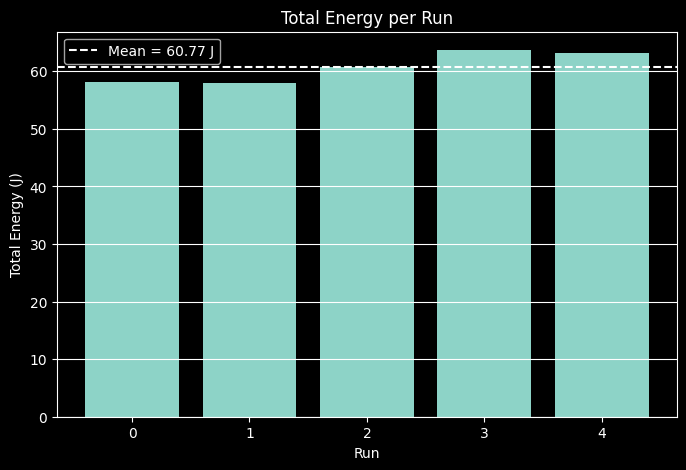

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(range(5), total_energies)
plt.axhline(mean_energy, linestyle='--', label=f"Mean = {mean_energy:.2f} J")
plt.xlabel("Run")
plt.ylabel("Total Energy (J)")
plt.title("Total Energy per Run")
plt.legend()
plt.grid(axis='y')
plt.show()